6.1 Setup & Analisis Distribusi Pre-Sampling

  SETUP KONFIRMASI — FASE 6 IMBALANCE HANDLING

  SRC_PATH           : C:\PORTFOLIO\PROJECTS\PBL\Predictive Maintenance\projects\predictive-maintenance-monorepo\machine_learning\src
  GLOBAL_SEED        : 42
  INPUT_PATH         : df_model_ready.parquet
  DATA_PROCESSED_DIR : C:\PORTFOLIO\PROJECTS\PBL\Predictive Maintenance\projects\predictive-maintenance-monorepo\machine_learning\data\processed

  Shape df           : (100000, 76)
  Kolom target       : health_label_encoded
  LABEL_MAP          : {'HEALTHY': 0, 'WARNING': 1, 'CRITICAL': 2}

  Distribusi awal    :
    0 (HEALTHY ) : 97,364
    1 (WARNING ) : 1,247
    2 (CRITICAL) : 1,389

  BAGIAN 1 — DISTRIBUSI GLOBAL

  Label       Code     Jumlah   Persentase
  ------------------------------------------
  HEALTHY        0     97,364     97.3640%
  WARNING        1      1,247      1.2470%
  CRITICAL       2      1,389      1.3890%
  ------------------------------------------
  TOTAL               100,000    100.0000%

--------------

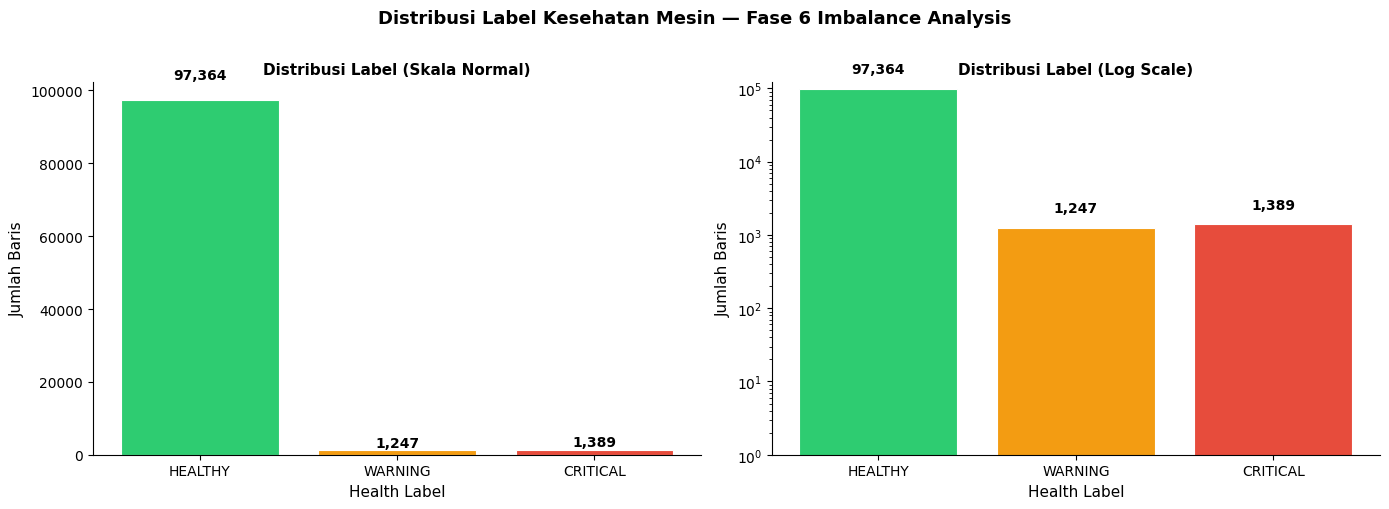


  BAGIAN 4 — REKOMENDASI STRATEGI

  Rasio HEALTHY / WARNING  : 78.1 : 1
  Rasio HEALTHY / CRITICAL : 70.1 : 1

  ⚠️  Ketimpangan EKSTREM pada kelas WARNING
      Rasio 78:1 jauh melampaui threshold 50:1
      → Hybrid Strategy diperlukan
  ⚠️  Ketimpangan EKSTREM pada kelas CRITICAL
      Rasio 70:1 jauh melampaui threshold 50:1
      → Hybrid Strategy diperlukan

-----------------------------------------------------------------
  STRATEGI YANG AKAN DITERAPKAN
-----------------------------------------------------------------

  Metode   : SMOTE + Tomek Links (SMOTETomek)
  Rationale:
    • SMOTE      → oversampling sintetis kelas minoritas
      (WARNING & CRITICAL) agar model dapat belajar pola pre-failure
    • Tomek Links → undersampling batas keputusan ambigu
      untuk memperjelas separasi antar kelas
    • Kombinasi ini menghindari bias HEALTHY yang dominan
      sekaligus menjaga distribusi data yang realistis

  [OK] Analisis distribusi selesai. df siap untuk Cell 2 (SMOTE).

In [1]:
# ============================================================
# FASE 6 — IMBALANCE HANDLING
# Cell 1: Setup + Analisis Distribusi Pre-Sampling
# ============================================================

import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# ----------------------------------------------------------
# [1] SYS.PATH SETUP
# Notebook: notebooks/fase_6_imbalance/
# ML_ROOT  = dua level ke atas
# ----------------------------------------------------------
NOTEBOOK_DIR = Path().resolve()
ML_ROOT      = NOTEBOOK_DIR.parent.parent
SRC_PATH     = ML_ROOT / "src"

if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

# ----------------------------------------------------------
# [2] IMPORT CONFIG
# ----------------------------------------------------------
from config import DATA_PROCESSED_DIR, DATA_INTERIM_DIR, GLOBAL_SEED, LABEL_MAP

np.random.seed(GLOBAL_SEED)

# ----------------------------------------------------------
# [3] LOAD DATA
# ----------------------------------------------------------
INPUT_PATH = DATA_PROCESSED_DIR / "df_model_ready.parquet"

df = pd.read_parquet(INPUT_PATH)

df = (
    df
    .sort_values(["machine_id", "timestamp"], ascending=True)
    .reset_index(drop=True)
)

# Reverse LABEL_MAP: {0: 'HEALTHY', 1: 'WARNING', 2: 'CRITICAL'}
LABEL_MAP_INV = {v: k for k, v in LABEL_MAP.items()}
TARGET_COL    = "health_label_encoded"

# ----------------------------------------------------------
# [4] KONFIRMASI SETUP
# ----------------------------------------------------------
SEP = "=" * 65
sep = "-" * 65

print(SEP)
print("  SETUP KONFIRMASI — FASE 6 IMBALANCE HANDLING")
print(SEP)
print(f"\n  SRC_PATH           : {SRC_PATH}")
print(f"  GLOBAL_SEED        : {GLOBAL_SEED}")
print(f"  INPUT_PATH         : {INPUT_PATH.name}")
print(f"  DATA_PROCESSED_DIR : {DATA_PROCESSED_DIR}")
print(f"\n  Shape df           : {df.shape}")
print(f"  Kolom target       : {TARGET_COL}")
print(f"  LABEL_MAP          : {LABEL_MAP}")
dist_awal = df[TARGET_COL].value_counts().sort_index()
print(f"\n  Distribusi awal    :")
for code, count in dist_awal.items():
    label = LABEL_MAP_INV.get(int(code), "?")
    print(f"    {code} ({label:<8}) : {count:,}")
print(SEP)

# ════════════════════════════════════════════════════════════
# BAGIAN 1 — DISTRIBUSI GLOBAL
# ════════════════════════════════════════════════════════════

print(f"\n{SEP}")
print("  BAGIAN 1 — DISTRIBUSI GLOBAL")
print(SEP)

counts    = df[TARGET_COL].value_counts().sort_index()
total     = len(df)

n_healthy  = int(counts.get(LABEL_MAP["HEALTHY"],  0))
n_warning  = int(counts.get(LABEL_MAP["WARNING"],  0))
n_critical = int(counts.get(LABEL_MAP["CRITICAL"], 0))

print(f"\n  {'Label':<10} {'Code':>5}  {'Jumlah':>9}  {'Persentase':>11}")
print(f"  {'-'*42}")
for label, code in LABEL_MAP.items():
    n   = int(counts.get(code, 0))
    pct = n / total * 100
    print(f"  {label:<10} {code:>5}  {n:>9,}  {pct:>10.4f}%")
print(f"  {'-'*42}")
print(f"  {'TOTAL':<10} {'':>5}  {total:>9,}  {'100.0000%':>11}")

# Rasio ketimpangan
ratio_h_w  = n_healthy / n_warning  if n_warning  > 0 else float("inf")
ratio_h_c  = n_healthy / n_critical if n_critical > 0 else float("inf")
ratio_w_c  = n_warning  / n_critical if n_critical > 0 else float("inf")

print(f"\n{sep}")
print("  RASIO KETIMPANGAN")
print(sep)
print(f"\n  HEALTHY  : WARNING   = {ratio_h_w:>8.1f} : 1")
print(f"  HEALTHY  : CRITICAL  = {ratio_h_c:>8.1f} : 1")
print(f"  WARNING  : CRITICAL  = {ratio_w_c:>8.2f} : 1")

# ════════════════════════════════════════════════════════════
# BAGIAN 2 — DISTRIBUSI PER MESIN
# ════════════════════════════════════════════════════════════

print(f"\n{SEP}")
print("  BAGIAN 2 — DISTRIBUSI PER MESIN")
print(SEP)

per_machine = (
    df.groupby("machine_id")[TARGET_COL]
    .value_counts()
    .unstack(fill_value=0)
    .rename_axis(None, axis=1)
    .reset_index()
)

# Pastikan semua kolom label ada
for label, code in LABEL_MAP.items():
    if code not in per_machine.columns:
        per_machine[code] = 0

# Rename kolom kode → nama label
col_rename = {v: f"n_{k}" for k, v in LABEL_MAP.items()}
per_machine = per_machine.rename(columns=col_rename)

# Hitung persentase WARNING dan CRITICAL per mesin
per_machine["pct_WARNING"]  = (
    per_machine["n_WARNING"]  / per_machine[["n_HEALTHY","n_WARNING","n_CRITICAL"]].sum(axis=1) * 100
).round(3)
per_machine["pct_CRITICAL"] = (
    per_machine["n_CRITICAL"] / per_machine[["n_HEALTHY","n_WARNING","n_CRITICAL"]].sum(axis=1) * 100
).round(3)

per_machine = per_machine.sort_values("machine_id")

print()
print(per_machine[[
    "machine_id", "n_HEALTHY", "n_WARNING", "n_CRITICAL",
    "pct_WARNING", "pct_CRITICAL"
]].to_string(index=False))

# Identifikasi mesin dengan WARNING atau CRITICAL = 0
zero_warning  = per_machine[per_machine["n_WARNING"]  == 0]["machine_id"].tolist()
zero_critical = per_machine[per_machine["n_CRITICAL"] == 0]["machine_id"].tolist()

print(f"\n{sep}")
print("  IDENTIFIKASI MESIN DENGAN LABEL NOL")
print(sep)
if zero_warning:
    print(f"\n  Mesin dengan WARNING  = 0 : {zero_warning}")
else:
    print(f"\n  [OK] Semua mesin memiliki data WARNING.")
if zero_critical:
    print(f"  Mesin dengan CRITICAL = 0 : {zero_critical}")
else:
    print(f"  [OK] Semua mesin memiliki data CRITICAL.")

# ════════════════════════════════════════════════════════════
# BAGIAN 3 — VISUALISASI
# ════════════════════════════════════════════════════════════

LABEL_NAMES = [LABEL_MAP_INV[i] for i in sorted(LABEL_MAP_INV.keys())]
LABEL_VALS  = [int(counts.get(LABEL_MAP[l], 0)) for l in LABEL_NAMES]
COLORS      = ["#2ecc71", "#f39c12", "#e74c3c"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Distribusi Label Kesehatan Mesin — Fase 6 Imbalance Analysis",
             fontsize=13, fontweight="bold", y=1.01)

for ax_idx, (ax, log_scale) in enumerate(zip(axes, [False, True])):
    bars = ax.bar(LABEL_NAMES, LABEL_VALS, color=COLORS,
                  edgecolor="white", linewidth=0.8)

    # Angka di atas bar
    for bar, val in zip(bars, LABEL_VALS):
        y_pos = bar.get_height() * (1.05 if not log_scale else 1.5)
        ax.text(bar.get_x() + bar.get_width() / 2,
                y_pos, f"{val:,}",
                ha="center", va="bottom", fontsize=10, fontweight="bold")

    ax.set_xlabel("Health Label", fontsize=11)
    ax.set_ylabel("Jumlah Baris", fontsize=11)
    title = ("Distribusi Label (Skala Normal)"
             if not log_scale else "Distribusi Label (Log Scale)")
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.spines[["top", "right"]].set_visible(False)

    if log_scale:
        ax.set_yscale("log")
        ax.set_ylim(bottom=1)

plt.tight_layout()
plt.show()

# ════════════════════════════════════════════════════════════
# BAGIAN 4 — REKOMENDASI STRATEGI
# ════════════════════════════════════════════════════════════

print(f"\n{SEP}")
print("  BAGIAN 4 — REKOMENDASI STRATEGI")
print(SEP)

print(f"\n  Rasio HEALTHY / WARNING  : {ratio_h_w:.1f} : 1")
print(f"  Rasio HEALTHY / CRITICAL : {ratio_h_c:.1f} : 1")

print()
if ratio_h_w > 50:
    print("  ⚠️  Ketimpangan EKSTREM pada kelas WARNING")
    print(f"      Rasio {ratio_h_w:.0f}:1 jauh melampaui threshold 50:1")
    print("      → Hybrid Strategy diperlukan")
if ratio_h_c > 50:
    print("  ⚠️  Ketimpangan EKSTREM pada kelas CRITICAL")
    print(f"      Rasio {ratio_h_c:.0f}:1 jauh melampaui threshold 50:1")
    print("      → Hybrid Strategy diperlukan")

print(f"\n{sep}")
print("  STRATEGI YANG AKAN DITERAPKAN")
print(sep)
print("\n  Metode   : SMOTE + Tomek Links (SMOTETomek)")
print("  Rationale:")
print("    • SMOTE      → oversampling sintetis kelas minoritas")
print("      (WARNING & CRITICAL) agar model dapat belajar pola pre-failure")
print("    • Tomek Links → undersampling batas keputusan ambigu")
print("      untuk memperjelas separasi antar kelas")
print("    • Kombinasi ini menghindari bias HEALTHY yang dominan")
print("      sekaligus menjaga distribusi data yang realistis")

print(f"\n{SEP}")
print("  [OK] Analisis distribusi selesai. df siap untuk Cell 2 (SMOTE).")
print(SEP)


6.2	Setup & Analisis Distribusi Pre-Sampling 

In [2]:
# ============================================================
# FASE 6 — Cell 2 (REFACTORED): SSBS Only — No SMOTE
# SMOTE akan diaplikasikan di Fase 7 pada X_train saja
# untuk mencegah Data Leakage temporal
# ============================================================

import numpy as np
import pandas as pd
import sys
from pathlib import Path

NOTEBOOK_DIR = Path().resolve()
ML_ROOT      = NOTEBOOK_DIR.parent.parent
SRC_PATH     = ML_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

from config import GLOBAL_SEED, DATA_PROCESSED_DIR, LABEL_MAP

np.random.seed(GLOBAL_SEED)

SEP = "=" * 65
sep = "-" * 65

LABEL_MAP_INV = {v: k for k, v in LABEL_MAP.items()}
TARGET_COL    = "health_label_encoded"

# ----------------------------------------------------------
# PARAMETER SAMPLING
# ----------------------------------------------------------
TARGET_HEALTHY      = 20_000
BLOCK_SIZE          = 500
SAFETY_BUFFER_HRS   = 24

N_MACHINES          = df["machine_id"].nunique()
QUOTA_PER_MACHINE   = TARGET_HEALTHY // N_MACHINES

COLS_EXCLUDE = [
    "timestamp", "machine_id", "health_label",
    "health_label_confirmed", "damage_category",
    "failure", "health_label_encoded",
]
FEATURE_COLS = [c for c in df.columns if c not in COLS_EXCLUDE]

print(SEP)
print("  PARAMETER SAMPLING — SSBS ONLY (No SMOTE)")
print(SEP)
print(f"\n  N_MACHINES          : {N_MACHINES}")
print(f"  TARGET_HEALTHY      : {TARGET_HEALTHY:,}")
print(f"  QUOTA_PER_MACHINE   : {QUOTA_PER_MACHINE:,}  "
      f"({TARGET_HEALTHY:,} / {N_MACHINES})")
print(f"  BLOCK_SIZE          : {BLOCK_SIZE:,} baris per blok")
print(f"  SAFETY_BUFFER_HRS   : {SAFETY_BUFFER_HRS} jam")
print(f"  FEATURE_COLS        : {len(FEATURE_COLS)} kolom")
print(f"\n  SMOTE              : TIDAK dijalankan di Fase 6")
print(f"  SMOTE akan diterapkan di Fase 7 pada X_train saja")

# ════════════════════════════════════════════════════════════
# BAGIAN 1 — SSBS UNTUK HEALTHY
# ════════════════════════════════════════════════════════════

print(f"\n{SEP}")
print("  BAGIAN 1 — STRATIFIED SEQUENTIAL BLOCK SAMPLING (HEALTHY)")
print(SEP)

def ssbs_healthy(df, quota_per_machine, block_size, safety_buffer_hrs):
    """
    Stratified Sequential Block Sampling untuk kelas HEALTHY.

    Per mesin:
    - Blok A : head(block_size) → kondisi prima mesin
    - Blok B : tail(block_size) → mendekati batas pre-warning
    - Safety buffer : hindari zona WARNING/CRITICAL
      untuk mencegah label leakage
    """
    sampled_parts = []

    for machine_id, df_machine in df.groupby("machine_id"):
        df_machine = df_machine.sort_values("timestamp")

        # Identifikasi T_safe_boundary
        warning_times = df_machine.loc[
            df_machine[TARGET_COL] == LABEL_MAP["WARNING"], "timestamp"
        ]

        if warning_times.empty:
            T_safe = df_machine["timestamp"].max()
        else:
            T_warning_first = warning_times.min()
            T_safe = T_warning_first - pd.Timedelta(hours=safety_buffer_hrs)

        # Filter HEALTHY sebelum T_safe
        df_healthy_safe = df_machine[
            (df_machine[TARGET_COL] == LABEL_MAP["HEALTHY"]) &
            (df_machine["timestamp"] < T_safe)
        ].sort_values("timestamp")

        n_available = len(df_healthy_safe)

        # Blok A: 500 baris pertama (kondisi prima)
        block_a = df_healthy_safe.head(block_size)

        # Blok B: 500 baris terakhir (pre-warning boundary)
        block_b = df_healthy_safe.tail(block_size)

        # Gabung, hilangkan duplikat (jika n_available < 1000)
        combined = pd.concat([block_a, block_b]).drop_duplicates()

        n_a   = len(block_a)
        n_b   = len(block_b)
        n_fin = len(combined)

        # Jika combined < quota: ambil semua (hormati data yang tersedia)
        if n_fin < quota_per_machine:
            final = df_healthy_safe
        else:
            final = combined

        print(f"  {machine_id}  |  T_safe={str(T_safe)[:16]}  "
              f"|  avail={n_available:>5,}  "
              f"|  A={n_a:>4}  B={n_b:>4}  "
              f"|  final={len(final):>5,}")

        sampled_parts.append(final)

    return pd.concat(sampled_parts).reset_index(drop=True)


print()
df_healthy_sampled = ssbs_healthy(
    df, QUOTA_PER_MACHINE, BLOCK_SIZE, SAFETY_BUFFER_HRS
)

print(f"\n{sep}")
print(f"  Shape df_healthy_sampled : {df_healthy_sampled.shape}")
print(f"  Total HEALTHY disampling : {len(df_healthy_sampled):,} baris")

# ════════════════════════════════════════════════════════════
# BAGIAN 2 — AMBIL SEMUA WARNING & CRITICAL (NATURAL)
# ════════════════════════════════════════════════════════════

print(f"\n{SEP}")
print("  BAGIAN 2 — AMBIL SEMUA WARNING & CRITICAL (NATURAL)")
print(SEP)

df_warning  = df[df[TARGET_COL] == LABEL_MAP["WARNING"]].copy()
df_critical = df[df[TARGET_COL] == LABEL_MAP["CRITICAL"]].copy()

print(f"\n  Shape df_warning  : {df_warning.shape}   "
      f"({len(df_warning):,} baris WARNING)")
print(f"  Shape df_critical : {df_critical.shape}  "
      f"({len(df_critical):,} baris CRITICAL)")

# ════════════════════════════════════════════════════════════
# BAGIAN 3 — GABUNGKAN (TANPA SMOTE)
# ════════════════════════════════════════════════════════════

print(f"\n{SEP}")
print("  BAGIAN 3 — GABUNGKAN SSBS DATASET (TANPA SMOTE)")
print(SEP)

# [1] Gabungkan
df_ssbs = (
    pd.concat([df_healthy_sampled, df_warning, df_critical])
    .sort_values(["machine_id", "timestamp"])
    .reset_index(drop=True)
)

# [2] Distribusi df_ssbs
print(f"\n{sep}")
print("  DISTRIBUSI health_label_encoded DI df_ssbs")
print(sep)
print()

dist = df_ssbs[TARGET_COL].value_counts().sort_index()
total = len(df_ssbs)
for code, cnt in dist.items():
    label = LABEL_MAP_INV.get(int(code), "?")
    pct   = cnt / total * 100
    print(f"    {code} ({label:<8}) : {cnt:>7,}  ({pct:.2f}%)")
print(f"    {'TOTAL':<12}  {total:>7,}")

# [3] Catatan arsitektur
print(f"\n{sep}")
print("  CATATAN ARSITEKTUR")
print(sep)
print()
print("  SMOTE TIDAK dijalankan di Fase 6.")
print("  SMOTE akan diaplikasikan HANYA pada X_train")
print("  setelah time-aware split di Fase 7.")
print("  Tujuan: mencegah Data Leakage temporal.")
print()
print("  Dengan pendekatan ini:")
print("  • Test set  → 100% data natural (tidak ada data sintetis)")
print("  • Val set   → 100% data natural")
print("  • Train set → SMOTE diterapkan setelah split")

# ════════════════════════════════════════════════════════════
# BAGIAN 4 — EXPORT
# ════════════════════════════════════════════════════════════

print(f"\n{SEP}")
print("  BAGIAN 4 — EXPORT df_ssbs")
print(SEP)

DATA_PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

PARQUET_PATH = DATA_PROCESSED_DIR / "df_ssbs.parquet"
CSV_PATH     = DATA_PROCESSED_DIR / "df_ssbs_preview.csv"

# Export Parquet
df_ssbs.to_parquet(PARQUET_PATH, index=False)
parquet_mb = PARQUET_PATH.stat().st_size / (1024 ** 2)

# Export CSV
df_ssbs.to_csv(CSV_PATH, index=False)
csv_mb = CSV_PATH.stat().st_size / (1024 ** 2)

print(f"\n{sep}")
print("  [FORMAT 1] Parquet — Pipeline Resmi")
print(sep)
print(f"\n  Path   : {PARQUET_PATH}")
print(f"  Shape  : {df_ssbs.shape}")
print(f"  Ukuran : {parquet_mb:.2f} MB")

print(f"\n{sep}")
print("  [FORMAT 2] CSV — Preview Manual")
print(sep)
print(f"\n  Path   : {CSV_PATH}")
print(f"  Shape  : {df_ssbs.shape}")
print(f"  Ukuran : {csv_mb:.2f} MB")

print(f"\n{sep}")
print("  CATATAN")
print(sep)
print("\n  df_ssbs.parquet adalah input resmi Fase 7 (Splitting & SMOTE).")

print(f"\n{SEP}")
print("  [OK] SSBS Sampling selesai. df_ssbs siap untuk Fase 7.")
print(SEP)


  PARAMETER SAMPLING — SSBS ONLY (No SMOTE)

  N_MACHINES          : 20
  TARGET_HEALTHY      : 20,000
  QUOTA_PER_MACHINE   : 1,000  (20,000 / 20)
  BLOCK_SIZE          : 500 baris per blok
  SAFETY_BUFFER_HRS   : 24 jam
  FEATURE_COLS        : 69 kolom

  SMOTE              : TIDAK dijalankan di Fase 6
  SMOTE akan diterapkan di Fase 7 pada X_train saja

  BAGIAN 1 — STRATIFIED SEQUENTIAL BLOCK SAMPLING (HEALTHY)

  M-01  |  T_safe=2025-09-27 04:00  |  avail=2,116  |  A= 500  B= 500  |  final=1,000
  M-02  |  T_safe=2025-08-22 23:00  |  avail=1,271  |  A= 500  B= 500  |  final=1,000
  M-03  |  T_safe=2025-09-07 23:00  |  avail=1,655  |  A= 500  B= 500  |  final=1,000
  M-04  |  T_safe=2025-08-09 16:00  |  avail=  952  |  A= 500  B= 500  |  final=  952
  M-05  |  T_safe=2025-08-21 06:00  |  avail=1,230  |  A= 500  B= 500  |  final=1,000
  M-06  |  T_safe=2025-07-22 19:00  |  avail=  523  |  A= 500  B= 500  |  final=  523
  M-07  |  T_safe=2025-08-22 06:00  |  avail=1,254  |  A= 500  B